In [1]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot
import OptimalBattery.estimate as et
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import SUITPy as suit


Default device set to: cuda


In [2]:
colors_list = [
    "#000000",  # 0 -> Black (Background)
    "#00FF00",  # 1 -> Green
    "#0000FF",  # 2 -> Blue
    "#FFFF00",  # 3 -> Yellow (Explicitly set)
    "#FF00FF",  # 4 -> Magenta
]

# Create a ListedColormap from the list
my_cmap = mcolors.ListedColormap(colors_list, name='my_8_color_map')

# define atlas and dirs

In [3]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
device = 'cuda' if pt.cuda.is_available() else 'cpu'

In [117]:
region_mapping = {
    (1, 2, 3, 4): 1,
    (5, 6, 7): 2,
    (8, 9, 10, 11): 3,
    (12, 13, 14, 15, 16): 4,
    (17, 18, 19, 20): 5,  
    (21, 22, 23): 6,
    (24, 25, 26, 27): 7,
    (28, 29, 30, 31, 32): 8
}

# functions

In [118]:
def compute_region_profiles(data_s2, contrast_data):
    n_subj, n_tasks, n_vox = data_s2.shape
    region_profiles = pt.zeros((n_subj, n_tasks, 1), device=data_s2.device)

    for s in range(n_subj):
        # Subject-specific mask
        mask_1 = (contrast_data[s] == 1)  
        for t in range(n_tasks):
            # Take the average activation for all voxels in mask_1
            region_profiles[s, t, 0] = data_s2[s, t, mask_1].mean()
    return region_profiles

def average_pairwise_correlation(region_profiles):

    # flatten the region_profiles (subj,taskprofiles)
    n_subj =region_profiles.shape[0]
    X = region_profiles.reshape(n_subj, -1).cpu().numpy()

    # get the correlation matrix among all subjects
    subjects_corr_matrix = np.corrcoef(X, rowvar=True)

    # get cross sub corrs
    i_upper, j_upper = np.triu_indices(n_subj, k=1)
    corrs = subjects_corr_matrix[i_upper, j_upper]

    return np.mean(corrs)

# Load data

In [119]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [120]:
task_names_s1  = info_mdtb_1_all['cond_name'].unique()
task_names_s2  = info_mdtb_2_all['cond_name'].unique()

# load condition dataframe
condition_df= ct.get_condition_indices(info_mdtb_1_run)

# multi dimesnional

load nettekoven atlas and reduce to 8 (low res)-> make field of view right hemi

In [8]:
# roi (full cerebellum)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation_32 = atlas.read_data(model_name)

flat_mapping = {k: v for keys, v in region_mapping.items() for k in keys}

# Vectorized mapping function
parcelation_8 = np.vectorize(lambda x: flat_mapping.get(int(x), x))(parcelation_32)


In [ ]:
ROI_to_include = [5,6,7,8] # all regions in the right hemisphere
# make a mask of the cerebellum
ROI_mask = np.isin(parcelation_8, ROI_to_include).astype(int)
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

2906

In [10]:
# make variables torch
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_test = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation_8, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


# find high dimensional battery

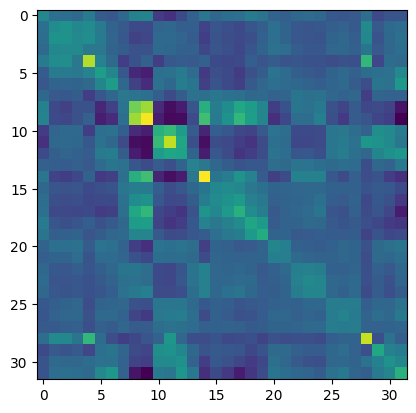

In [11]:
cond_vec = np.tile(np.arange(1, 32 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 32)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib, cmap='viridis')

In [92]:
D = ct.build_combinations(G_Lib, strategy='random',n_batteries=100000,n_tasks=8,seed=1,replacement=False,rest_idx=None)
# find row with the highest log_det_mc
best_row = D.loc[D['log_det_mc'].idxmax()]
combination = best_row['combination']
# combination = (28,19)
# print(combination)

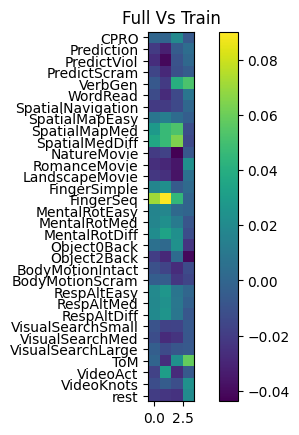

In [93]:
full_vs_train = et.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask=ROI_mask)
plt.imshow(full_vs_train.cpu().numpy(), cmap='viridis')
plt.colorbar()
plt.title('Full Vs Train')
plt.yticks(np.arange(full_vs_train.shape[0]), task_names_s1)
plt.show()

In [94]:
regressor_list = ct.build_combination_regressors(combination,condition_df,5)
YLib_subset = ct.average_regressors(data_train,regressor_list)
YLib_subset = ut.center_matrix(YLib_subset, axis=1)
YLib_subset = ut.normalize_matrix(YLib_subset, axis=1)

VLib  = full_vs_train
# get the Vs for the combination
VLib_subset = VLib[combination, :]
VLib_subset = ut.center_matrix(VLib_subset, axis=0)
VLib_subset = ut.normalize_matrix(VLib_subset, axis=0)

U_hats = et.estimate_Us(YLib_subset, VLib_subset,method='correlation',hard=True)
U_hats_num = pt.argmax(U_hats, axis=1).to(dtype=pt.float32) + 1.0
U_hats_num_masked = U_hats_num * ROI_mask


In [95]:
pt.unique(U_hats_num_masked[2])

tensor([0., 1., 2., 3., 4.], device='cuda:0')

plot parcellations

In [96]:
# fig, axes = plt.subplots(4, 6, figsize=(18, 12))
# axes = axes.flatten()

# for i in range(24):
#     U_hat = U_hats_num_masked[i, :].cpu().numpy()
#     nifti = atlas.data_to_nifti(U_hat)
#     surface = suit.flatmap.vol_to_surf(nifti, space='SUIT', stats='mode')

#     plt.sca(axes[i])  
#     suit.flatmap.plot(
#         data=surface,
#         cmap=my_cmap,
#         render='matplotlib',
#         new_figure=False, 
#         colorbar=False
#     )

# plt.tight_layout()
# plt.show()


In [97]:
regiona = 3
U_hats_binary = (U_hats_num_masked == regiona).to(dtype=pt.float32)

size_list = []
for i in range(U_hats_binary.shape[0]):
    size_list.append(int(U_hats_binary[i].sum().cpu().numpy().item()))
    print(f"Subject {i}: {U_hats_binary[i].sum()} voxels")

Subject 0: 467.0 voxels
Subject 1: 1568.0 voxels
Subject 2: 849.0 voxels
Subject 3: 902.0 voxels
Subject 4: 1027.0 voxels
Subject 5: 841.0 voxels
Subject 6: 784.0 voxels
Subject 7: 620.0 voxels
Subject 8: 786.0 voxels
Subject 9: 745.0 voxels
Subject 10: 522.0 voxels
Subject 11: 944.0 voxels
Subject 12: 256.0 voxels
Subject 13: 385.0 voxels
Subject 14: 1426.0 voxels
Subject 15: 799.0 voxels
Subject 16: 350.0 voxels
Subject 17: 388.0 voxels
Subject 18: 505.0 voxels
Subject 19: 551.0 voxels
Subject 20: 989.0 voxels
Subject 21: 961.0 voxels
Subject 22: 829.0 voxels
Subject 23: 656.0 voxels


# single dimensional localizers

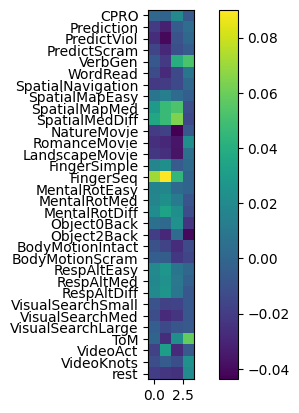

In [98]:
plt.imshow(full_vs_train.cpu().numpy())
plt.colorbar()
plt.yticks(np.arange(0,full_vs_train.shape[0]),task_names_s1)
plt.show()

find best contrast for region of interest and the one closest to it

In [99]:
def find_single_contrast(Vs, regionA, regionB):
    difference = Vs[:, regionA -1] - Vs[:, regionB-1]
    sorted_idx = pt.argsort(difference) 

    min_idx = sorted_idx[0].item()
    max_idx = sorted_idx[-1].item()

    return [max_idx, min_idx]

In [100]:
regiona = 3
regionb = 4
single_combination = find_single_contrast(full_vs_train, regiona, regionb)
single_combination

[9, 11]

# make the contrast with a certain arbitrary threshold

In [101]:
combination_regressors = ct.build_combination_regressors(single_combination, condition_df,localizer_time=5)
YLib_subset = ct.average_regressors(data_train, combination_regressors)
combination_regressors

[[169, 201, 137, 457, 329, 489, 361, 9, 105, 265, 297, 425, 233, 393, 41],
 [107, 203, 395, 331, 299]]

In [102]:
def thresholded_contrast(task1, task2, threshold=0.85):
    contrast_data = task1 - task2  # Compute contrast
    contrast_data = contrast_data * ROI_mask
    
    if threshold is not None:
        valid_values = contrast_data[contrast_data != 0]
        # Compute per-subject thresholds
        subject_thresholds = pt.quantile(valid_values, threshold, dim=1, keepdim=True)
        subject_thresholds = pt.quantile(contrast_data, threshold, dim=1, keepdim=True) 
        
        # Apply thresholding: values below threshold -> -1, above threshold -> 1
        thresholded_data = pt.where(contrast_data < subject_thresholds, -1, 1).float()
        thresholded_data = thresholded_data * ROI_mask
        
    
    return thresholded_data

def size_matched_contrast(task1, task2, ROI_mask, subject_size_list):
    contrast_data = task1 - task2  
    contrast_data = contrast_data * ROI_mask 
    
    thresholded_data = pt.zeros_like(contrast_data)  #
    for i in range(task1.shape[0]):  
        num_voxels_to_include = subject_size_list[i]
        subject_contrast = contrast_data[i]  

        # Get only valid (nonzero, within-field of view) voxel indices
        valid_voxel_indices = pt.nonzero(subject_contrast, as_tuple=True)[0]  
        valid_voxel_values = subject_contrast[valid_voxel_indices]
        sorted_indices = pt.argsort(valid_voxel_values, descending=True)
        
        # Select the top num_voxels_to_include
        selected_indices = valid_voxel_indices[sorted_indices[:num_voxels_to_include]]

        # Set selected voxels to 1, keeping the rest as 0
        thresholded_data[i].scatter_(0, selected_indices, pt.ones_like(selected_indices, dtype=subject_contrast.dtype))

    return thresholded_data




contrast_data = size_matched_contrast(YLib_subset[:,0,:],YLib_subset[:,1,:],ROI_mask=ROI_mask,subject_size_list=size_list)
contrast_data = contrast_data * ROI_mask



In [103]:
# for i in range(24):
#     contrast_subject = contrast_data[i,:]
#     contrast_subject = contrast_subject.cpu().numpy()
#     nifti = atlas.data_to_nifti(contrast_subject)
#     surface = suit.flatmap.vol_to_surf(nifti, space='SUIT',stats='mode')
#     suit.flatmap.plot(data=surface, cmap='viridis', new_figure=True, colorbar=True, render='matplotlib')


In [104]:
for i in range(contrast_data.shape[0]):
    size_list.append(int(contrast_data[i].sum().cpu().numpy().item()))
    print(f"Subject {i}: {contrast_data[i].sum()} voxels")

Subject 0: 467.0 voxels
Subject 1: 1568.0 voxels
Subject 2: 849.0 voxels
Subject 3: 902.0 voxels
Subject 4: 1027.0 voxels
Subject 5: 841.0 voxels
Subject 6: 784.0 voxels
Subject 7: 620.0 voxels
Subject 8: 786.0 voxels
Subject 9: 745.0 voxels
Subject 10: 522.0 voxels
Subject 11: 944.0 voxels
Subject 12: 256.0 voxels
Subject 13: 385.0 voxels
Subject 14: 1426.0 voxels
Subject 15: 799.0 voxels
Subject 16: 350.0 voxels
Subject 17: 388.0 voxels
Subject 18: 505.0 voxels
Subject 19: 551.0 voxels
Subject 20: 989.0 voxels
Subject 21: 961.0 voxels
Subject 22: 829.0 voxels
Subject 23: 656.0 voxels


# compute thw profile of the tasks within the region of interest

In [105]:

# 2) Compute region profiles on Session 2 data
region_profiles = compute_region_profiles(data_test, contrast_data)

# 3) Compute average pairwise correlation across subjects
avg_corr = average_pairwise_correlation(region_profiles)
print(f" Mean pairwise correlation={avg_corr:.4f}")
    


 Mean pairwise correlation=0.4195


In [106]:

# 2) Compute region profiles on Session 2 data
region_profiles = compute_region_profiles(data_test, U_hats_binary)

# 3) Compute average pairwise correlation across subjects
avg_corr = average_pairwise_correlation(region_profiles)
print(f" Mean pairwise correlation={avg_corr:.4f}")

 Mean pairwise correlation=0.3519


# dcbc

In [112]:
from DCBC.dcbc import compute_DCBC
import DCBC.utilities as util

In [113]:
dist_matrix = util.compute_dist(atlas.world.T[ROI_indices,:], resolution=1)
dist_matrix = pt.tensor(dist_matrix, dtype=pt.float32, device=device)
dist_matrix.shape

torch.Size([2906, 2906])

In [114]:
masked_contrast = contrast_data[:, ROI_indices]
masked_test = data_test[:, :, ROI_indices]

In [115]:
dcbc_list = []
for i in range(masked_contrast.shape[0]):
    masked_contrast_subject = masked_contrast[i]
    masked_test_subject = masked_test[i]
    masked_test_subject = masked_test_subject.T
    D = compute_DCBC(parcellation=masked_contrast_subject,func = masked_test_subject,dist = dist_matrix,backend='torch')
    dcbc_value = D['DCBC']
    dcbc_list.append(dcbc_value)

print(dcbc_list)
dcbc_tensor = pt.stack(dcbc_list)
print(dcbc_tensor.mean())


[tensor(-0.0152, device='cuda:0'), tensor(0.1037, device='cuda:0'), tensor(-0.0058, device='cuda:0'), tensor(0.2000, device='cuda:0'), tensor(0.0440, device='cuda:0'), tensor(0.1071, device='cuda:0'), tensor(0.0028, device='cuda:0'), tensor(-0.0066, device='cuda:0'), tensor(0.0222, device='cuda:0'), tensor(0.0602, device='cuda:0'), tensor(0.1063, device='cuda:0'), tensor(0.0786, device='cuda:0'), tensor(0.0003, device='cuda:0'), tensor(0.0508, device='cuda:0'), tensor(0.0661, device='cuda:0'), tensor(0.0155, device='cuda:0'), tensor(0.0315, device='cuda:0'), tensor(0.0318, device='cuda:0'), tensor(-0.0085, device='cuda:0'), tensor(-0.0170, device='cuda:0'), tensor(0.0829, device='cuda:0'), tensor(0.0779, device='cuda:0'), tensor(-0.0055, device='cuda:0'), tensor(0.0309, device='cuda:0')]
tensor(0.0439, device='cuda:0')


In [116]:
masked_us = U_hats_binary[:, ROI_indices]
dcbc_list = []
for i in range(masked_us.shape[0]):
    masked_us_subject = masked_us[i]
    masked_test_subject = masked_test[i]
    masked_test_subject = masked_test_subject.T
    D = compute_DCBC(parcellation=masked_us_subject,func = masked_test_subject,dist = dist_matrix,backend='torch')
    dcbc_value = D['DCBC']
    dcbc_list.append(dcbc_value)

print(dcbc_list)
dcbc_tensor = pt.stack(dcbc_list)
print(dcbc_tensor.mean())

[tensor(0.0033, device='cuda:0'), tensor(0.1334, device='cuda:0'), tensor(-0.0121, device='cuda:0'), tensor(0.1236, device='cuda:0'), tensor(0.0136, device='cuda:0'), tensor(0.0931, device='cuda:0'), tensor(-0.0055, device='cuda:0'), tensor(-0.0456, device='cuda:0'), tensor(-0.0058, device='cuda:0'), tensor(0.0355, device='cuda:0'), tensor(0.0918, device='cuda:0'), tensor(0.0407, device='cuda:0'), tensor(0.0143, device='cuda:0'), tensor(0.0033, device='cuda:0'), tensor(0.0192, device='cuda:0'), tensor(0.0245, device='cuda:0'), tensor(0.0031, device='cuda:0'), tensor(0.0091, device='cuda:0'), tensor(0.0176, device='cuda:0'), tensor(-0.0010, device='cuda:0'), tensor(0.0571, device='cuda:0'), tensor(0.0263, device='cuda:0'), tensor(-0.0272, device='cuda:0'), tensor(0.0079, device='cuda:0')]
tensor(0.0258, device='cuda:0')
